# Intraday Momentum — Implementation Comparison

Loads standardized signal trades from `results/intraday_momentum_trades.csv`
and tests multiple sizing implementations.

**Implementations:**
1. Simple flat bet (85%)
2. Risk-based (1% risk) across leverage levels (1×, 2×, 4×, 8×, 12×)
3. Rolling Kelly (full, half, quarter)
4. Volatility targeting — strategy vol (10% annualized)
5. Asset vol targeting — generic per-trade (SPY vol, 14d lookback, 4× cap)
6. Intraday asset vol — paper's EXACT method (daily sizing, same shares all day)

**Key question:** Does the paper's dynamic leverage (sizing by SPY vol)
beat simpler alternatives?

**Note:** The paper sizes ONCE per day at the open — all trades that day use
the same share count. `intraday_asset_vol` replicates this exactly.
`asset_vol_targeting` is a generic per-trade version for comparison.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _shared.implementations import (
    simple_bet, risk_based, kelly_sizing, vol_targeting,
    asset_vol_targeting, intraday_asset_vol, compare_implementations
)

STARTING_CAPITAL = 100_000
STRATEGY_NAME = "Intraday Momentum"

pd.set_option("display.max_columns", None)

## 2. Load Signal Trades

In [2]:
trades = pd.read_csv("results/intraday_momentum_trades.csv", parse_dates=["entry_time", "exit_time"])
print(f"Loaded {len(trades)} trades")
print(f"Period: {trades['entry_time'].iloc[0].date()} → {trades['exit_time'].iloc[-1].date()}")
print(f"Columns: {list(trades.columns)}")
print(f"Has stop_price: {trades['stop_price'].notna().sum()} / {len(trades)}")

# Load SPY daily prices for asset vol targeting
spy_daily = pd.read_csv("results/spy_daily_prices.csv", parse_dates=["date"])
print(f"\nSPY daily prices: {len(spy_daily)} days, columns: {list(spy_daily.columns)}")


Loaded 2304 trades
Period: 2016-01-25 → 2026-03-31
Columns: ['entry_time', 'exit_time', 'direction', 'instrument', 'entry_price', 'exit_price', 'pct_return_gross', 'exit_reason', 'stop_price']
Has stop_price: 2304 / 2304

SPY daily prices: 2575 days, columns: ['date', 'day_open', 'day_close']


## 3. Sizing Comparison (No Leverage)

All implementations at 1× leverage for apples-to-apples comparison.

In [3]:
# ── Simple bet ────────────────────────────────────────────────────────────────
r_simple = simple_bet(trades, bet_size=0.85)

# ── Risk-based (1× — cap binding, same as simple 100%) ──────────────────────
r_risk_1x = risk_based(trades, risk_pct=0.01, leverage=1)

# ── Kelly variants ────────────────────────────────────────────────────────────
r_kelly_full    = kelly_sizing(trades, fraction=1.0, burn_in=100)
r_kelly_half    = kelly_sizing(trades, fraction=0.5, burn_in=100)
r_kelly_quarter = kelly_sizing(trades, fraction=0.25, burn_in=100)

# ── Vol targeting (strategy vol) ──────────────────────────────────────────────
r_vol = vol_targeting(trades, target_vol=0.10, lookback=60)

# ── Asset vol targeting (per-trade sizing) ────────────────────────────────────
r_asset_vol = asset_vol_targeting(trades, spy_daily.set_index("date")["day_close"],
                                   target_vol=0.02, lookback=14, max_leverage=4.0)

# ── Intraday asset vol (paper's exact method — day-level sizing) ─────────────
r_intraday_vol = intraday_asset_vol(trades, spy_daily, target_vol=0.02,
                                     lookback=14, max_leverage=4.0)

base_results = [r_simple, r_risk_1x, r_kelly_full, r_kelly_half,
                r_kelly_quarter, r_vol, r_asset_vol, r_intraday_vol]

print("ALL IMPLEMENTATIONS (base):")
compare_implementations(base_results)

ALL IMPLEMENTATIONS (base):

Implementation                      Return       CAGR       Sharpe     Sortino    MaxDD      WinRate    PF        
Simple (85% bet)                        71.4%      6.1%      1.02      1.75      -8.8%     44.9%     1.26
Risk-based (1% risk, 1× lev)            70.0%      6.0%      0.97      1.52     -10.3%     44.8%     1.22
Full Kelly (burn-in=100)                -0.1%     -0.0%     -0.43     -0.14      -0.1%      1.3%     0.69
Half Kelly (burn-in=100)                -0.1%     -0.0%     -0.43     -0.14      -0.1%      1.3%     0.69
Quarter Kelly (burn-in=100)             -0.1%     -0.0%     -0.43     -0.14      -0.1%      1.3%     0.69
Vol target (10% ann, 2× max lev)       134.6%      9.8%      1.14      2.34     -10.3%     44.9%     1.29
Asset vol (2%, 14d, 4× max)            141.2%     10.1%      0.81      1.54     -19.2%     44.9%     1.17
Intraday asset vol (2%, 14d, 4× max)    590.1%     23.5%      1.52      3.23     -17.3%     46.2%     1.37


## 4. Risk-Based Leverage Sweep

At 1× every trade buys `equity / price` shares (capital constrained).
At higher leverage, the risk formula sizes trades by stop distance.

In [4]:
LEVERAGE_LEVELS = [1, 2, 4, 8, 12]

leverage_results = []
for lev in LEVERAGE_LEVELS:
    r = risk_based(trades, risk_pct=0.01, leverage=lev)
    leverage_results.append(r)

print("RISK-BASED — LEVERAGE SWEEP:")
compare_implementations(leverage_results)

RISK-BASED — LEVERAGE SWEEP:

Implementation                      Return       CAGR       Sharpe     Sortino    MaxDD      WinRate    PF        
Risk-based (1% risk, 1× lev)            70.0%      6.0%      0.97      1.52     -10.3%     44.8%     1.22
Risk-based (1% risk, 2× lev)            91.7%      7.4%      0.70      1.09     -18.1%     44.8%     1.14
Risk-based (1% risk, 4× lev)            -9.1%     -1.0%      0.04      0.06     -37.7%     44.8%     1.01
Risk-based (1% risk, 8× lev)           -92.2%    -24.3%     -0.76     -1.10     -93.2%     44.8%     0.87
Risk-based (1% risk, 12× lev)          -99.3%    -42.2%     -1.20     -1.64     -99.4%     44.8%     0.80


## 5. Vol Targeting Leverage Sweep

Compare different max leverage caps for both strategy-vol and asset-vol targeting.

In [5]:
vol_lev_results = []

# Strategy vol with different max leverage
for max_lev in [1, 2, 4, 8]:
    r = vol_targeting(trades, target_vol=0.10, lookback=60, max_leverage=max_lev)
    vol_lev_results.append(r)

# Asset vol (per-trade) with different max leverage
for max_lev in [2, 4, 8]:
    r = asset_vol_targeting(trades, spy_daily.set_index("date")["day_close"],
                             target_vol=0.02, lookback=14, max_leverage=max_lev)
    vol_lev_results.append(r)

# Intraday asset vol (paper method) with different max leverage
for max_lev in [2, 4, 8]:
    r = intraday_asset_vol(trades, spy_daily, target_vol=0.02,
                            lookback=14, max_leverage=max_lev)
    vol_lev_results.append(r)

print("VOL TARGETING — LEVERAGE SWEEP:")
compare_implementations(vol_lev_results)

VOL TARGETING — LEVERAGE SWEEP:

Implementation                      Return       CAGR       Sharpe     Sortino    MaxDD      WinRate    PF        
Vol target (10% ann, 1× max lev)        94.2%      7.5%      1.11      1.95      -9.0%     44.9%     1.29
Vol target (10% ann, 2× max lev)       134.6%      9.8%      1.14      2.34     -10.3%     44.9%     1.29
Vol target (10% ann, 4× max lev)       137.3%      9.9%      1.15      2.35     -10.3%     44.9%     1.29
Vol target (10% ann, 8× max lev)       136.3%      9.9%      1.14      2.33     -10.3%     44.9%     1.29
Asset vol (2%, 14d, 2× max)            151.0%     10.6%      1.04      1.96     -14.3%     44.9%     1.23
Asset vol (2%, 14d, 4× max)            141.2%     10.1%      0.81      1.54     -19.2%     44.9%     1.17
Asset vol (2%, 14d, 8× max)             99.6%      7.9%      0.63      1.13     -28.7%     44.9%     1.12
Intraday asset vol (2%, 14d, 2× max)    313.3%     16.8%      1.47      2.98     -13.6%     46.2%     1.36
Int

## 7. All Models Equity Curves

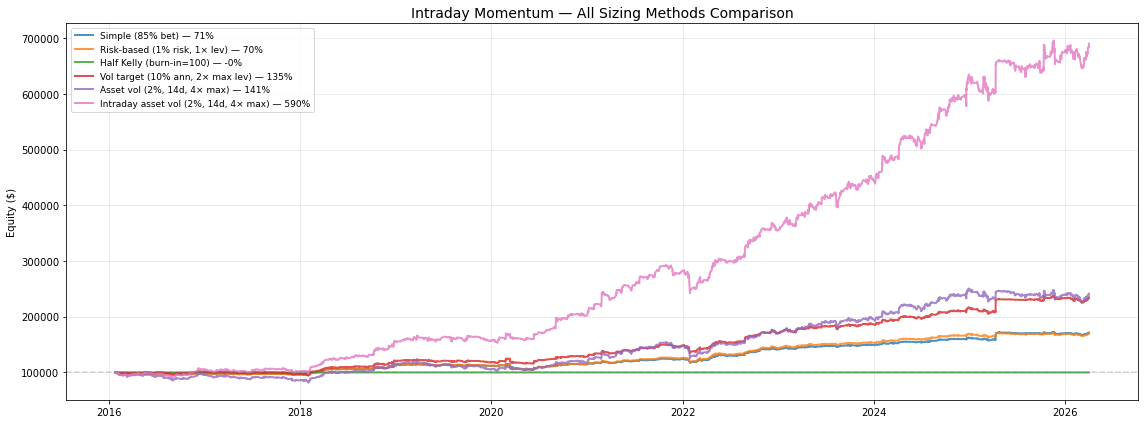

In [7]:

# Best of each category
all_compare = [r_simple, r_risk_1x, r_kelly_half, r_vol, r_asset_vol, r_intraday_vol]

fig, ax = plt.subplots(figsize=(16, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#e377c2"]

for r, c in zip(all_compare, colors):
    eq = r["equity_curve"]
    ret = (eq[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(dates[:len(eq)], eq, linewidth=2, color=c, alpha=0.8,
            label=f"{r['label']} — {ret:,.0f}%")

ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} — All Sizing Methods Comparison", fontsize=14)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

## 8. Save Implementation Stats

In [8]:
import json

impl_summary = {}

# Save all base models
for r in base_results:
    key = r["label"].lower().replace(" ", "_").replace("(", "").replace(")", "")\
         .replace("%", "pct").replace("=", "").replace(",", "").replace("×", "x")
    impl_summary[key] = r["stats"]
    impl_summary[key]["label"] = r["label"]

# Save all leverage levels
for r in leverage_results:
    key = r["label"].lower().replace(" ", "_").replace("(", "").replace(")", "")\
         .replace("%", "pct").replace("=", "").replace(",", "").replace("×", "x")
    impl_summary[key] = r["stats"]
    impl_summary[key]["label"] = r["label"]

# Flag recommended (best Sharpe with MaxDD > -50%)
all_viable = [r for r in base_results + leverage_results if r["stats"]["max_dd"] > -50]
if all_viable:
    best_viable = max(all_viable, key=lambda r: r["stats"]["sharpe"])
    impl_summary["_recommended"] = best_viable["label"]

    print(f"Recommended: {best_viable['label']}")
    print(f"  Sharpe={best_viable['stats']['sharpe']}, Return={best_viable['stats']['total_return']}%, "
          f"MaxDD={best_viable['stats']['max_dd']}%")

with open("results/intraday_momentum_implementations.json", "w") as f:
    json.dump(impl_summary, f, indent=2)
print(f"\nSaved {len(impl_summary) - 1} implementations → results/intraday_momentum_implementations.json")

Recommended: Intraday asset vol (2%, 14d, 4× max)
  Sharpe=1.52, Return=590.1%, MaxDD=-17.3%

Saved 12 implementations → results/intraday_momentum_implementations.json


## 9. Conclusion

**Key comparisons:**
- Simple bet vs. paper's intraday asset-vol — does dynamic leverage add value?
- Generic asset vol (per-trade) vs. intraday asset vol (per-day) — structural difference matters
- Risk-based with leverage sweep — does stop-based sizing outperform?
- Strategy vol vs. asset vol targeting — which vol measure is better for sizing?

**For the PM:** pick the implementation with the best Sharpe at acceptable MaxDD.
The recommended implementation is flagged in the JSON output.